# Demand Forecasting with Prophet

Прогноз недельных продаж и количества проданных товаров глобального
Superstore на основе исторических данных за 2011–2014 годы.

## Цель проекта

Построить модель Prophet для прогноза спроса на четыре недели вперёд,
оценить качество прогноза с помощью MAPE и RMSE и сравнить модель
с сезонным базовым прогнозом.

## Основные результаты

- MAPE прогноза продаж: 8,13%
- RMSE прогноза продаж: 11 896,96
- Prophet снизил RMSE относительно baseline на 54,6%
- MAPE прогноза количества товаров: 8,00%
- Прогноз продаж на первые четыре недели 2015 года: 339 797

In [1]:
!pip -q install prophet openpyxl

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from prophet import Prophet
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error
)

pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

from openpyxl.styles import Font, Alignment
from openpyxl.utils import get_column_letter


def save_excel_table(
    dataframe,
    filename,
    sheet_name='Data'
):
    """
    Сохраняет DataFrame в аккуратный Excel-файл:
    - отдельные столбцы;
    - жирная шапка;
    - фильтры;
    - закреплённая первая строка;
    - автоматическая ширина колонок;
    - нормальный формат дат.
    """

    with pd.ExcelWriter(
        filename,
        engine='openpyxl',
        date_format='YYYY-MM-DD',
        datetime_format='YYYY-MM-DD'
    ) as writer:

        dataframe.to_excel(
            writer,
            sheet_name=sheet_name,
            index=False
        )

        worksheet = writer.sheets[sheet_name]


        worksheet.freeze_panes = 'A2'


        worksheet.auto_filter.ref = worksheet.dimensions


        for cell in worksheet[1]:
            cell.font = Font(bold=True)
            cell.alignment = Alignment(
                horizontal='center',
                vertical='center'
            )


        for column_number, column_name in enumerate(
            dataframe.columns,
            start=1
        ):
            column_letter = get_column_letter(column_number)

            values = [
                str(column_name)
            ] + [
                str(value)
                for value in dataframe[column_name].head(1000)
                if pd.notna(value)
            ]

            max_length = max(
                len(value)
                for value in values
            )

            worksheet.column_dimensions[
                column_letter
            ].width = min(
                max(max_length + 2, 12),
                35
            )


            if pd.api.types.is_datetime64_any_dtype(
                dataframe[column_name]
            ):
                for cell in worksheet[column_letter][1:]:
                    cell.number_format = 'yyyy-mm-dd'


            elif pd.api.types.is_integer_dtype(
                dataframe[column_name]
            ):
                for cell in worksheet[column_letter][1:]:
                    cell.number_format = '#,##0'


            elif pd.api.types.is_float_dtype(
                dataframe[column_name]
            ):
                for cell in worksheet[column_letter][1:]:
                    cell.number_format = '#,##0.00'

In [3]:
from google.colab import files

uploaded = files.upload()

Saving SuperStoreOrders.csv to SuperStoreOrders (6).csv


In [4]:
import pandas as pd

df = pd.read_csv(
    'SuperStoreOrders.csv',
    encoding='utf-8-sig'
)

df.columns = (
    df.columns
    .str.replace('\ufeff', '', regex=False)
    .str.replace('ï»¿', '', regex=False)
    .str.strip()
)

df['sales'] = pd.to_numeric(
    df['sales']
    .astype(str)
    .str.replace(',', '', regex=False),
    errors='raise'
)

df['quantity'] = pd.to_numeric(
    df['quantity'],
    errors='raise'
)

df['order_date'] = pd.to_datetime(
    df['order_date'],
    dayfirst=True,
    format='mixed',
    errors='raise'
)

print(df[['order_date', 'sales', 'quantity']].isna().sum())

df.to_csv(
    'sales_clean.csv',
    index=False,
    encoding='utf-8-sig'
)

order_date    0
sales         0
quantity      0
dtype: int64


In [5]:
before = len(df)

df = (
    df
    .dropna(subset=['order_date', 'sales'])
    .sort_values('order_date')
    .reset_index(drop=True)
)

after = len(df)

print('Удалено строк:', before - after)
print('Минимальная дата:', df['order_date'].min())
print('Максимальная дата:', df['order_date'].max())
print('Общая сумма продаж:', df['sales'].sum())

Удалено строк: 0
Минимальная дата: 2011-01-01 00:00:00
Максимальная дата: 2014-12-31 00:00:00
Общая сумма продаж: 12642905


In [6]:
min_date = df['order_date'].min().normalize()
max_date = df['order_date'].max().normalize()

days_to_monday = (7 - min_date.dayofweek) % 7
first_complete_week_start = min_date + pd.Timedelta(days=days_to_monday)

days_from_sunday = (max_date.dayofweek + 1) % 7
last_complete_week_end = max_date - pd.Timedelta(days=days_from_sunday)

print('Первая полная неделя начинается:', first_complete_week_start)
print('Последняя полная неделя заканчивается:', last_complete_week_end)

Первая полная неделя начинается: 2011-01-03 00:00:00
Последняя полная неделя заканчивается: 2014-12-28 00:00:00


In [7]:
df_full_weeks = df[
    (df['order_date'] >= first_complete_week_start) &
    (df['order_date'] <= last_complete_week_end)
].copy()

weekly = (
    df_full_weeks
    .set_index('order_date')['sales']
    .resample('W-SUN')
    .sum()
    .reset_index()
    .rename(columns={
        'order_date': 'ds',
        'sales': 'y'
    })
)

print('Количество недель:', len(weekly))
print('Начало ряда:', weekly['ds'].min())
print('Конец ряда:', weekly['ds'].max())

weekly.head()

Количество недель: 208
Начало ряда: 2011-01-09 00:00:00
Конец ряда: 2014-12-28 00:00:00


,ds,y
0,2011-01-09,25830
1,2011-01-16,27175
2,2011-01-23,21796
3,2011-01-30,15336
4,2011-02-06,20268


In [8]:
print(weekly.info())
print('\nПропуски:')
print(weekly.isna().sum())

print('\nОсновная статистика:')
display(weekly['y'].describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 208 entries, 0 to 207
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   ds      208 non-null    datetime64[ns]
 1   y       208 non-null    int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 3.4 KB
None

Пропуски:
ds    0
y     0
dtype: int64

Основная статистика:


,y
count,208.00
mean,"60,512.43"
std,"27,150.52"
min,"15,336.00"
25%,"39,547.25"
50%,"55,662.00"
75%,"77,540.50"
max,"162,934.00"


In [9]:
date_diff = weekly['ds'].diff().dropna()

print(date_diff.value_counts())

ds
7 days    207
Name: count, dtype: int64


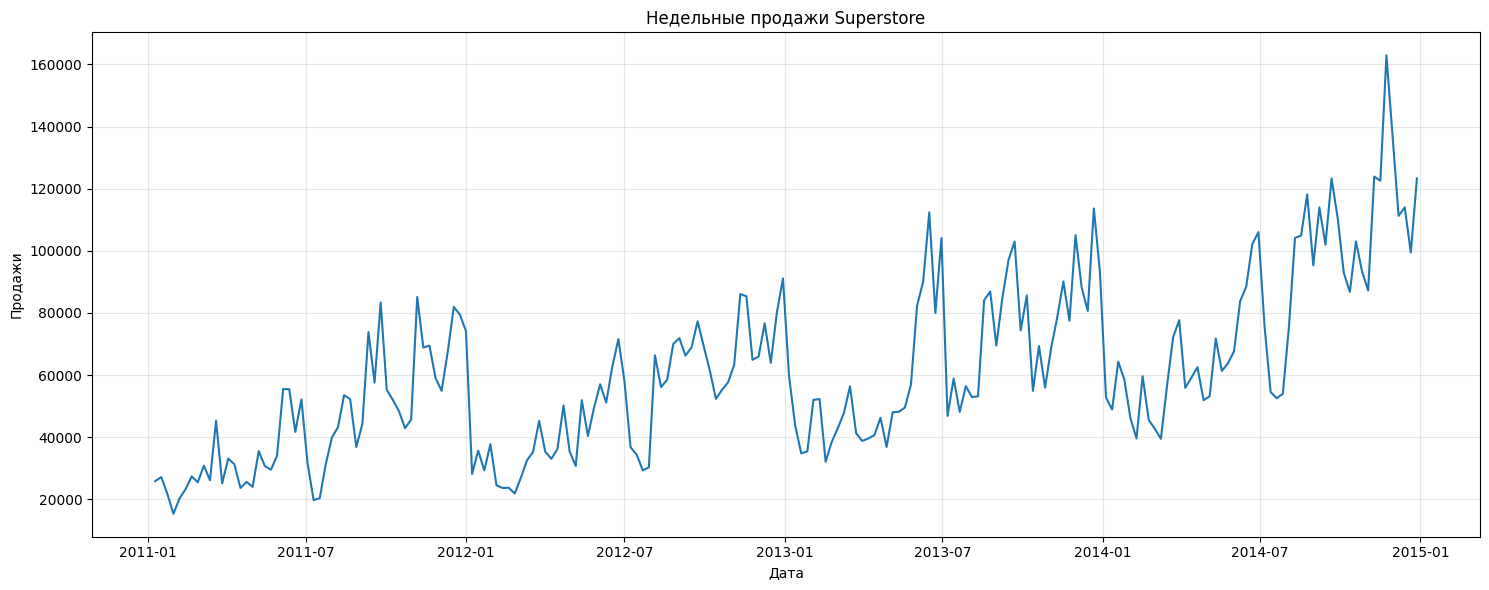

In [10]:
plt.figure(figsize=(15, 6))

plt.plot(
    weekly['ds'],
    weekly['y'],
    linewidth=1.5
)

plt.title('Недельные продажи Superstore')
plt.xlabel('Дата')
plt.ylabel('Продажи')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

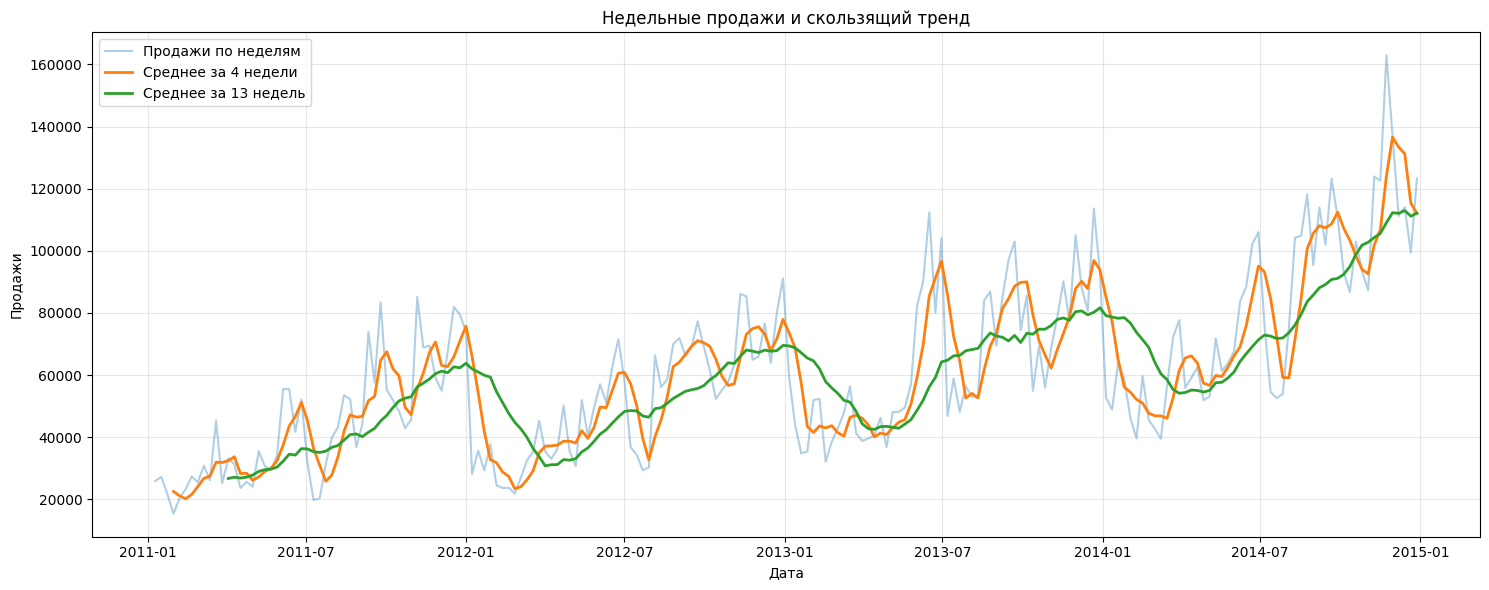

In [11]:
weekly['rolling_4w'] = weekly['y'].rolling(4).mean()
weekly['rolling_13w'] = weekly['y'].rolling(13).mean()

plt.figure(figsize=(15, 6))

plt.plot(
    weekly['ds'],
    weekly['y'],
    alpha=0.35,
    label='Продажи по неделям'
)

plt.plot(
    weekly['ds'],
    weekly['rolling_4w'],
    linewidth=2,
    label='Среднее за 4 недели'
)

plt.plot(
    weekly['ds'],
    weekly['rolling_13w'],
    linewidth=2,
    label='Среднее за 13 недель'
)

plt.title('Недельные продажи и скользящий тренд')
plt.xlabel('Дата')
plt.ylabel('Продажи')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [12]:
FORECAST_HORIZON = 4

if len(weekly) <= FORECAST_HORIZON:
    raise ValueError('Недостаточно данных для разделения на train и test')

train = weekly.iloc[:-FORECAST_HORIZON][['ds', 'y']].copy()
test = weekly.iloc[-FORECAST_HORIZON:][['ds', 'y']].copy()

print('Train:')
print(train['ds'].min(), '—', train['ds'].max())
print('Количество недель:', len(train))

print('\nTest:')
print(test['ds'].min(), '—', test['ds'].max())
print('Количество недель:', len(test))

display(test)

Train:
2011-01-09 00:00:00 — 2014-11-30 00:00:00
Количество недель: 204

Test:
2014-12-07 00:00:00 — 2014-12-28 00:00:00
Количество недель: 4


,ds,y
204,2014-12-07,111233
205,2014-12-14,113997
206,2014-12-21,99448
207,2014-12-28,123279


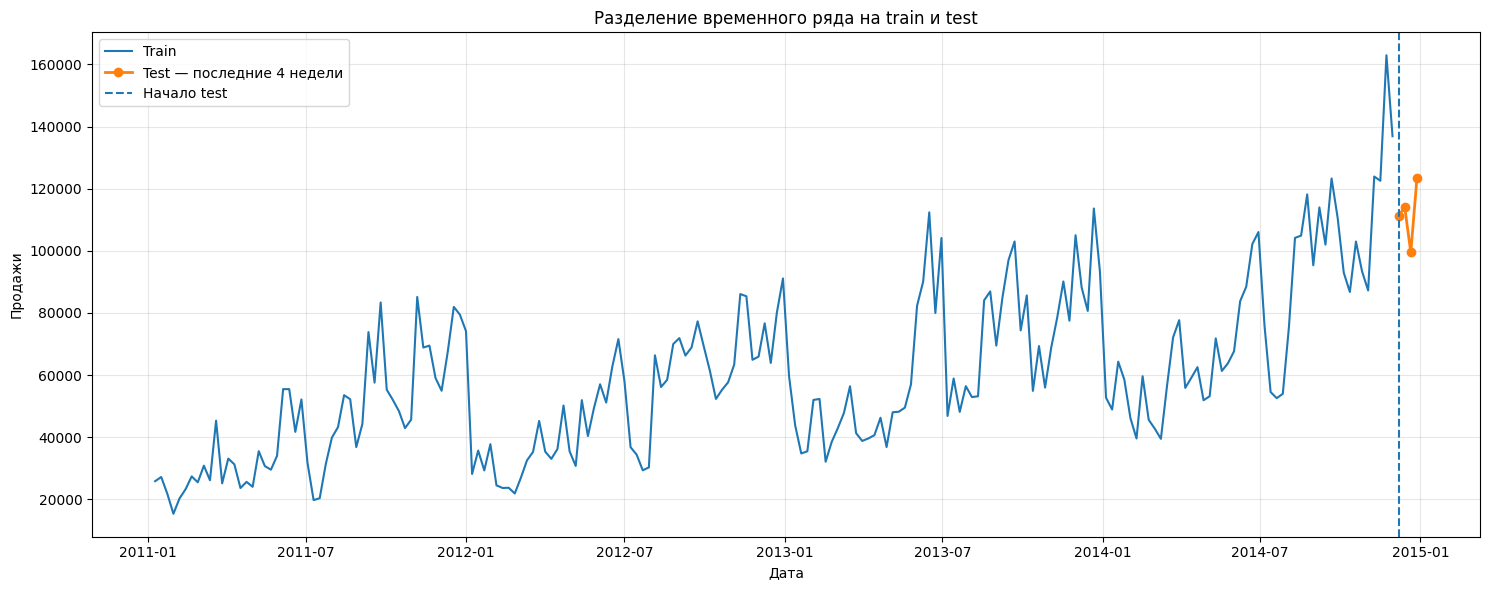

In [13]:
plt.figure(figsize=(15, 6))

plt.plot(
    train['ds'],
    train['y'],
    label='Train'
)

plt.plot(
    test['ds'],
    test['y'],
    marker='o',
    linewidth=2,
    label='Test — последние 4 недели'
)

plt.axvline(
    test['ds'].min(),
    linestyle='--',
    label='Начало test'
)

plt.title('Разделение временного ряда на train и test')
plt.xlabel('Дата')
plt.ylabel('Продажи')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [14]:
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode='additive',
    interval_width=0.80
)

model.fit(train)

In [15]:
test_forecast = model.predict(
    test[['ds']]
)

results = test.merge(
    test_forecast[
        ['ds', 'yhat', 'yhat_lower', 'yhat_upper']
    ],
    on='ds',
    how='left'
)

for column in ['yhat', 'yhat_lower', 'yhat_upper']:
    results[column] = results[column].clip(lower=0)

results['error'] = results['y'] - results['yhat']
results['abs_error'] = results['error'].abs()
results['ape_pct'] = (
    results['abs_error'] /
    results['y'].replace(0, np.nan)
) * 100

display(results.round(2))

,ds,y,yhat,yhat_lower,yhat_upper,error,abs_error,ape_pct
0,2014-12-07,111233,"113,336.29","99,319.33","126,352.02","-2,103.29","2,103.29",1.89
1,2014-12-14,113997,"117,927.21","104,570.08","131,875.81","-3,930.21","3,930.21",3.45
2,2014-12-21,99448,"122,215.49","109,404.41","136,071.55","-22,767.49","22,767.49",22.89
3,2014-12-28,123279,"117,994.92","103,636.49","131,202.59","5,284.08","5,284.08",4.29


In [16]:
non_zero_mask = results['y'] != 0

if non_zero_mask.sum() == 0:
    mape = np.nan
else:
    mape = mean_absolute_percentage_error(
        results.loc[non_zero_mask, 'y'],
        results.loc[non_zero_mask, 'yhat']
    ) * 100

rmse = np.sqrt(
    mean_squared_error(
        results['y'],
        results['yhat']
    )
)

mae = mean_absolute_error(
    results['y'],
    results['yhat']
)

forecast_accuracy = max(0, 100 - mape) if pd.notna(mape) else np.nan

print(f'MAPE: {mape:.2f}%')
print(f'RMSE: {rmse:,.2f}')
print(f'MAE: {mae:,.2f}')
print(f'Условная точность: {forecast_accuracy:.2f}%')

MAPE: 8.13%
RMSE: 11,896.96
MAE: 8,521.27
Условная точность: 91.87%


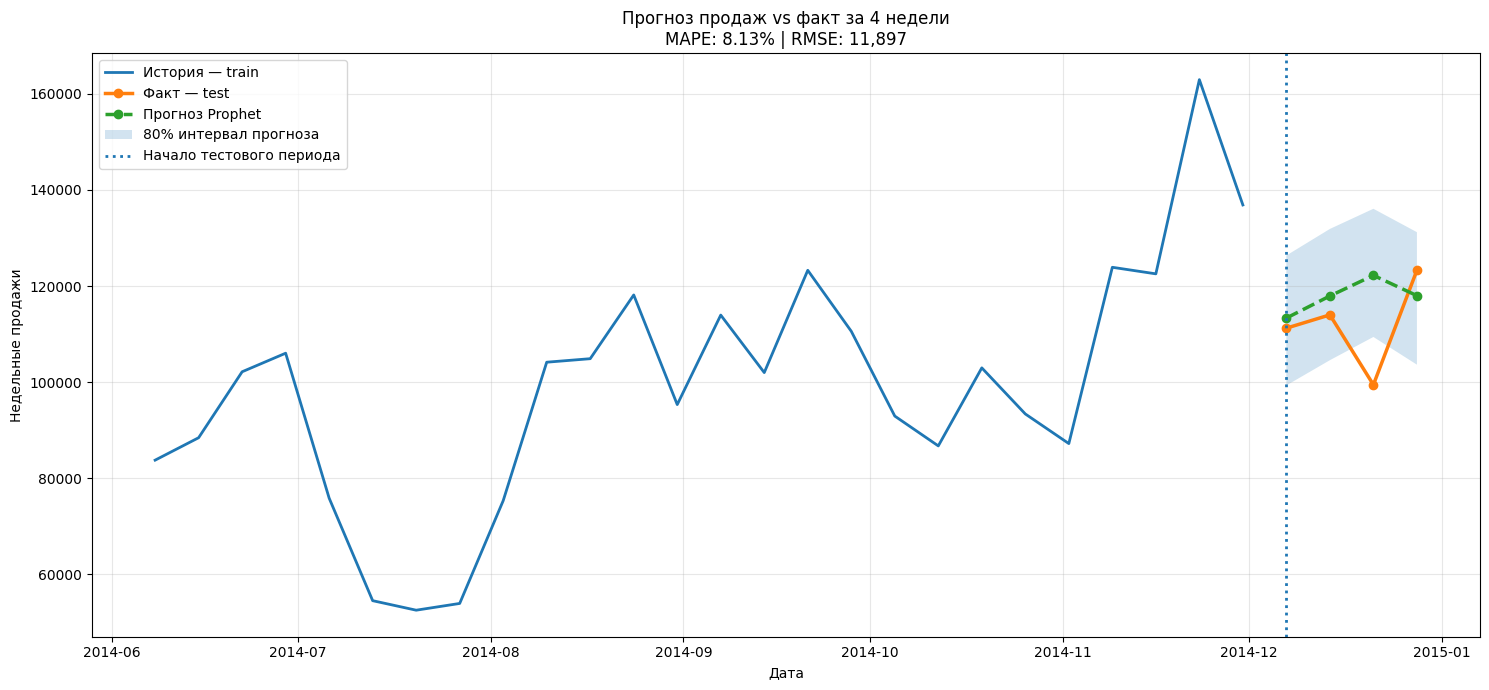

In [17]:
plt.figure(figsize=(15, 7))

train_tail = train.tail(26)

plt.plot(
    train_tail['ds'],
    train_tail['y'],
    linewidth=2,
    label='История — train'
)

plt.plot(
    results['ds'],
    results['y'],
    marker='o',
    linewidth=2.5,
    label='Факт — test'
)

plt.plot(
    results['ds'],
    results['yhat'],
    marker='o',
    linestyle='--',
    linewidth=2.5,
    label='Прогноз Prophet'
)

plt.fill_between(
    results['ds'],
    results['yhat_lower'],
    results['yhat_upper'],
    alpha=0.2,
    label='80% интервал прогноза'
)

plt.axvline(
    results['ds'].min(),
    linestyle=':',
    linewidth=2,
    label='Начало тестового периода'
)

plt.title(
    f'Прогноз продаж vs факт за 4 недели\n'
    f'MAPE: {mape:.2f}% | RMSE: {rmse:,.0f}'
)

plt.xlabel('Дата')
plt.ylabel('Недельные продажи')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [18]:
comparison = results[
    [
        'ds',
        'y',
        'yhat',
        'yhat_lower',
        'yhat_upper',
        'abs_error',
        'ape_pct'
    ]
].copy()

comparison.columns = [
    'week',
    'actual_sales',
    'forecast_sales',
    'forecast_lower',
    'forecast_upper',
    'absolute_error',
    'percentage_error'
]

display(comparison.round(2))

,week,actual_sales,forecast_sales,forecast_lower,forecast_upper,absolute_error,percentage_error
0,2014-12-07,111233,"113,336.29","99,319.33","126,352.02","2,103.29",1.89
1,2014-12-14,113997,"117,927.21","104,570.08","131,875.81","3,930.21",3.45
2,2014-12-21,99448,"122,215.49","109,404.41","136,071.55","22,767.49",22.89
3,2014-12-28,123279,"117,994.92","103,636.49","131,202.59","5,284.08",4.29


In [19]:

comparison.to_csv(
    'forecast_vs_actual.csv',
    index=False,
    encoding='utf-8-sig'
)

save_excel_table(
    comparison,
    'forecast_vs_actual.xlsx',
    sheet_name='Forecast vs Actual'
)

from google.colab import files

files.download('forecast_vs_actual.csv')
files.download('forecast_vs_actual.xlsx')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [20]:
weekly_baseline = weekly[['ds', 'y']].copy()
weekly_baseline['seasonal_naive'] = weekly_baseline['y'].shift(52)

baseline_test = weekly_baseline.iloc[-FORECAST_HORIZON:].copy()

baseline_rmse = np.sqrt(
    mean_squared_error(
        baseline_test['y'],
        baseline_test['seasonal_naive']
    )
)

baseline_mape = mean_absolute_percentage_error(
    baseline_test['y'],
    baseline_test['seasonal_naive']
) * 100

print(f'Prophet MAPE: {mape:.2f}%')
print(f'Базовый MAPE: {baseline_mape:.2f}%')
print()
print(f'Prophet RMSE: {rmse:,.2f}')
print(f'Базовый RMSE: {baseline_rmse:,.2f}')

Prophet MAPE: 8.13%
Базовый MAPE: 22.15%

Prophet RMSE: 11,896.96
Базовый RMSE: 26,213.43


In [21]:
if rmse < baseline_rmse:
    improvement = (baseline_rmse - rmse) / baseline_rmse * 100

    print(
        f'Prophet снизил RMSE относительно сезонного '
        f'базового прогноза на {improvement:.1f}%.'
    )
else:
    print(
        'Prophet не превзошёл сезонный базовый прогноз. '
        'Нужно проверить параметры модели и выбросы.'
    )

Prophet снизил RMSE относительно сезонного базового прогноза на 54.6%.


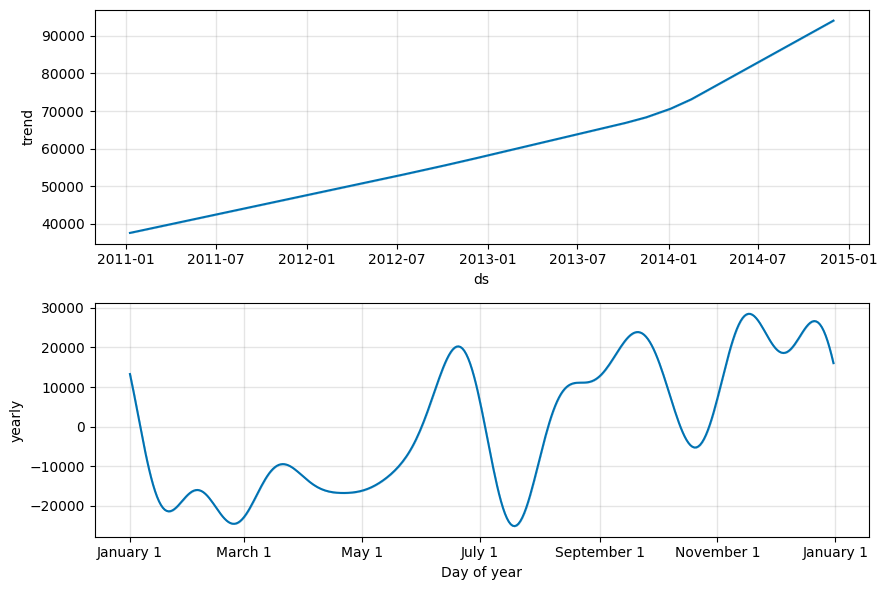

In [22]:
history_forecast = model.predict(
    train[['ds']]
)

model.plot_components(history_forecast)
plt.show()

In [23]:
from prophet.diagnostics import (
    cross_validation,
    performance_metrics
)

cv_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode='additive',
    interval_width=0.80
)

cv_model.fit(weekly[['ds', 'y']])

df_cv = cross_validation(
    cv_model,
    initial='730 days',
    period='90 days',
    horizon='28 days'
)

cv_metrics = performance_metrics(
    df_cv,
    rolling_window=1
)

display(cv_metrics)

INFO:prophet:Making 8 forecasts with cutoffs between 2013-03-10 00:00:00 and 2014-11-30 00:00:00


  0%|          | 0/8 [00:00<?, ?it/s]

,horizon,mse,rmse,mae,mape,mdape,smape,coverage
0,28 days,"252,401,914.71","15,887.16","12,582.32",0.15,0.14,0.16,0.50


In [24]:
cv_mape = cv_metrics['mape'].mean() * 100
cv_rmse = cv_metrics['rmse'].mean()

print(f'Cross-validation MAPE: {cv_mape:.2f}%')
print(f'Cross-validation RMSE: {cv_rmse:,.2f}')

Cross-validation MAPE: 15.16%
Cross-validation RMSE: 15,887.16


In [25]:
final_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode='additive',
    interval_width=0.80
)

final_model.fit(
    weekly[['ds', 'y']]
)

In [26]:
future = final_model.make_future_dataframe(
    periods=4,
    freq='W-SUN'
)

final_forecast = final_model.predict(future)

next_4_weeks = final_forecast[
    final_forecast['ds'] > weekly['ds'].max()
][
    ['ds', 'yhat', 'yhat_lower', 'yhat_upper']
].copy()

for column in ['yhat', 'yhat_lower', 'yhat_upper']:
    next_4_weeks[column] = next_4_weeks[column].clip(lower=0)

next_4_weeks.columns = [
    'week',
    'forecast_sales',
    'forecast_lower',
    'forecast_upper'
]

display(next_4_weeks.round(2))

,week,forecast_sales,forecast_lower,forecast_upper
208,2015-01-04,"102,140.97","89,164.36","114,189.00"
209,2015-01-11,"85,990.72","72,166.92","98,552.43"
210,2015-01-18,"76,061.72","63,037.13","88,976.66"
211,2015-01-25,"75,603.51","61,976.55","88,379.01"


In [27]:
total_forecast = next_4_weeks['forecast_sales'].sum()
total_lower = next_4_weeks['forecast_lower'].sum()
total_upper = next_4_weeks['forecast_upper'].sum()

print(f'Прогноз продаж за 4 недели: {total_forecast:,.2f}')
print(
    f'Ориентировочный диапазон: '
    f'{total_lower:,.2f} — {total_upper:,.2f}'
)

Прогноз продаж за 4 недели: 339,796.92
Ориентировочный диапазон: 286,344.96 — 390,097.09


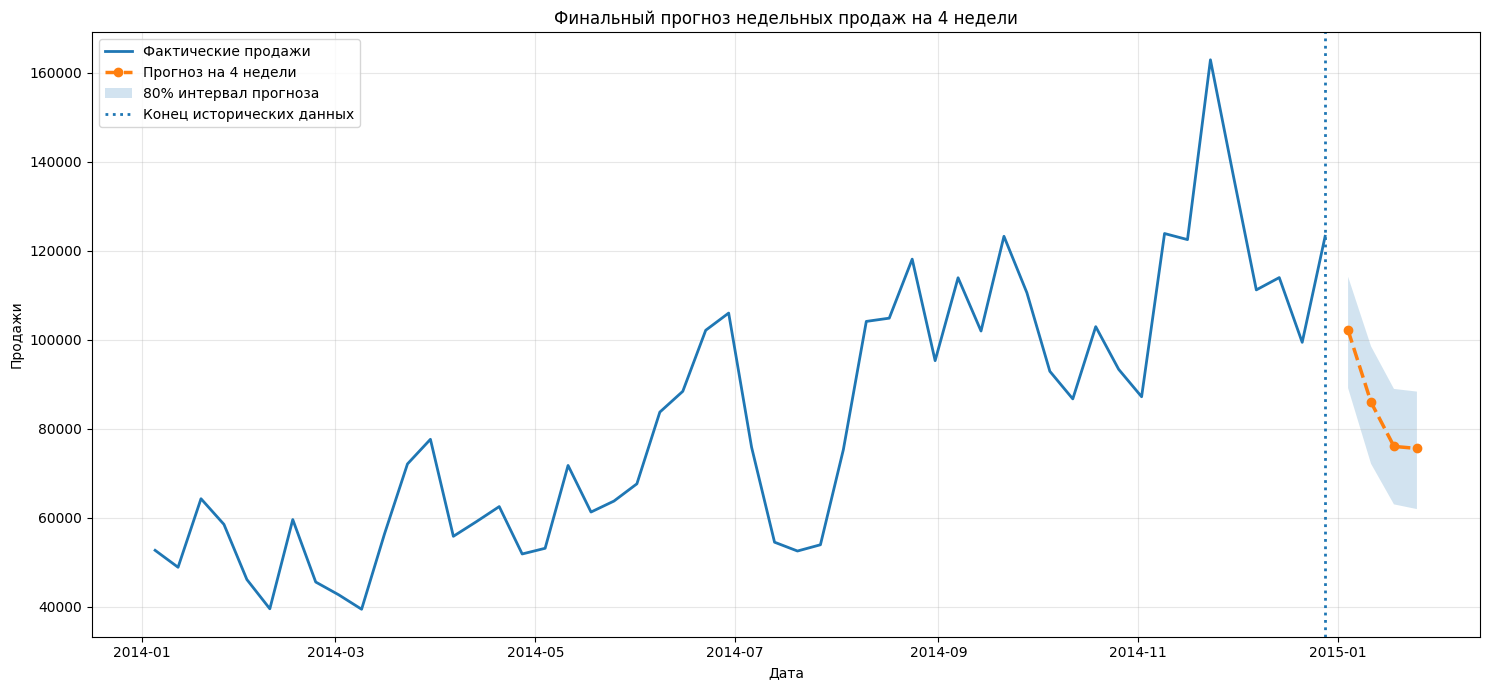

In [28]:
plt.figure(figsize=(15, 7))

history_for_plot = weekly.tail(52)

plt.plot(
    history_for_plot['ds'],
    history_for_plot['y'],
    linewidth=2,
    label='Фактические продажи'
)

plt.plot(
    next_4_weeks['week'],
    next_4_weeks['forecast_sales'],
    marker='o',
    linestyle='--',
    linewidth=2.5,
    label='Прогноз на 4 недели'
)

plt.fill_between(
    next_4_weeks['week'],
    next_4_weeks['forecast_lower'],
    next_4_weeks['forecast_upper'],
    alpha=0.2,
    label='80% интервал прогноза'
)

plt.axvline(
    weekly['ds'].max(),
    linestyle=':',
    linewidth=2,
    label='Конец исторических данных'
)

plt.title('Финальный прогноз недельных продаж на 4 недели')
plt.xlabel('Дата')
plt.ylabel('Продажи')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [29]:

next_4_weeks.to_csv(
    'next_4_weeks_forecast.csv',
    index=False,
    encoding='utf-8-sig'
)

save_excel_table(
    next_4_weeks,
    'next_4_weeks_forecast.xlsx',
    sheet_name='4 Week Forecast'
)

from google.colab import files

files.download('next_4_weeks_forecast.csv')
files.download('next_4_weeks_forecast.xlsx')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [30]:
weekly_sales_export = weekly[
    ['ds', 'y']
].copy()

weekly_sales_export.to_csv(
    'weekly_sales.csv',
    index=False,
    encoding='utf-8-sig'
)

save_excel_table(
    weekly_sales_export,
    'weekly_sales.xlsx',
    sheet_name='Weekly Sales'
)

from google.colab import files

files.download('weekly_sales.csv')
files.download('weekly_sales.xlsx')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [31]:
print(
    f'Модель Prophet прогнозирует недельные продажи '
    f'на 4 недели вперёд с MAPE {mape:.1f}%. '
    f'Условная точность составляет {forecast_accuracy:.1f}%. '
    f'Ожидаемый суммарный объём продаж за следующие '
    f'4 недели — {total_forecast:,.0f}. '
    f'Прогноз позволяет заранее планировать закупки, '
    f'распределение запасов и логистические мощности, '
    f'что снижает риск дефицита товара и избыточных запасов.'
)

Модель Prophet прогнозирует недельные продажи на 4 недели вперёд с MAPE 8.1%. Условная точность составляет 91.9%. Ожидаемый суммарный объём продаж за следующие 4 недели — 339,797. Прогноз позволяет заранее планировать закупки, распределение запасов и логистические мощности, что снижает риск дефицита товара и избыточных запасов.


In [32]:
weekly_quantity = (
    df_full_weeks
    .set_index('order_date')['quantity']
    .resample('W-SUN')
    .sum()
    .reset_index()
    .rename(columns={
        'order_date': 'ds',
        'quantity': 'y'
    })
)

In [33]:
QUANTITY_FORECAST_HORIZON = 4

In [34]:
if len(weekly_quantity) <= QUANTITY_FORECAST_HORIZON:
    raise ValueError(
        'Недостаточно данных для разделения quantity на train и test'
    )

In [35]:
quantity_train = (
    weekly_quantity
    .iloc[:-QUANTITY_FORECAST_HORIZON][['ds', 'y']]
    .copy()
)

quantity_test = (
    weekly_quantity
    .iloc[-QUANTITY_FORECAST_HORIZON:][['ds', 'y']]
    .copy()
)

print('TRAIN — количество проданных единиц:')
print(
    quantity_train['ds'].min(),
    '—',
    quantity_train['ds'].max()
)
print('Количество недель:', len(quantity_train))

print('\nTEST — последние 4 недели:')
print(
    quantity_test['ds'].min(),
    '—',
    quantity_test['ds'].max()
)
print('Количество недель:', len(quantity_test))

display(quantity_test)

TRAIN — количество проданных единиц:
2011-01-09 00:00:00 — 2014-11-30 00:00:00
Количество недель: 204

TEST — последние 4 недели:
2014-12-07 00:00:00 — 2014-12-28 00:00:00
Количество недель: 4


,ds,y
204,2014-12-07,1758
205,2014-12-14,1715
206,2014-12-21,1450
207,2014-12-28,1675


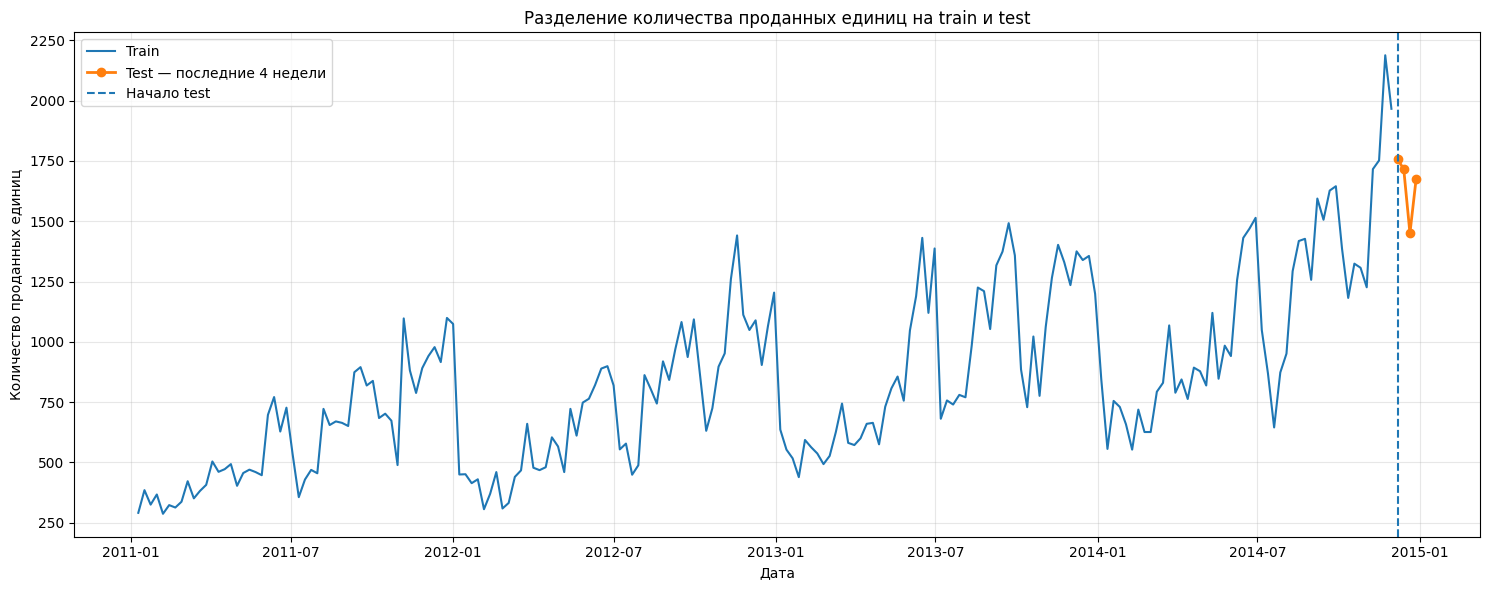

In [36]:
plt.figure(figsize=(15, 6))

plt.plot(
    quantity_train['ds'],
    quantity_train['y'],
    label='Train'
)

plt.plot(
    quantity_test['ds'],
    quantity_test['y'],
    marker='o',
    linewidth=2,
    label='Test — последние 4 недели'
)

plt.axvline(
    quantity_test['ds'].min(),
    linestyle='--',
    label='Начало test'
)

plt.title(
    'Разделение количества проданных единиц на train и test'
)
plt.xlabel('Дата')
plt.ylabel('Количество проданных единиц')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [37]:
quantity_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode='additive',
    interval_width=0.80
)

In [38]:
quantity_model.fit(quantity_train)

In [39]:
quantity_test_forecast = quantity_model.predict(
    quantity_test[['ds']]
)

quantity_results = quantity_test.merge(
    quantity_test_forecast[
        ['ds', 'yhat', 'yhat_lower', 'yhat_upper']
    ],
    on='ds',
    how='left'
)

In [40]:

for column in ['yhat', 'yhat_lower', 'yhat_upper']:
    quantity_results[column] = (
        quantity_results[column].clip(lower=0)
    )

quantity_results['error'] = (
    quantity_results['y']
    - quantity_results['yhat']
)

quantity_results['abs_error'] = (
    quantity_results['error'].abs()
)

quantity_results['ape_pct'] = (
    quantity_results['abs_error']
    / quantity_results['y'].replace(0, np.nan)
) * 100

print('\nПрогноз количества vs факт:')
display(quantity_results.round(2))






Прогноз количества vs факт:


,ds,y,yhat,yhat_lower,yhat_upper,error,abs_error,ape_pct
0,2014-12-07,1758,"1,627.31","1,482.10","1,775.04",130.69,130.69,7.43
1,2014-12-14,1715,"1,645.68","1,504.65","1,789.85",69.32,69.32,4.04
2,2014-12-21,1450,"1,656.55","1,513.59","1,800.61",-206.55,206.55,14.24
3,2014-12-28,1675,"1,570.09","1,412.79","1,717.00",104.91,104.91,6.26


In [41]:

quantity_non_zero_mask = quantity_results['y'] != 0

if quantity_non_zero_mask.sum() == 0:
    quantity_mape = np.nan
else:
    quantity_mape = mean_absolute_percentage_error(
        quantity_results.loc[
            quantity_non_zero_mask,
            'y'
        ],
        quantity_results.loc[
            quantity_non_zero_mask,
            'yhat'
        ]
    ) * 100

quantity_rmse = np.sqrt(
    mean_squared_error(
        quantity_results['y'],
        quantity_results['yhat']
    )
)

quantity_mae = mean_absolute_error(
    quantity_results['y'],
    quantity_results['yhat']
)

quantity_accuracy = (
    max(0, 100 - quantity_mape)
    if pd.notna(quantity_mape)
    else np.nan
)

print(f'Quantity MAPE: {quantity_mape:.2f}%')
print(f'Quantity RMSE: {quantity_rmse:,.2f}')
print(f'Quantity MAE: {quantity_mae:,.2f}')
print(
    f'Условная точность quantity: '
    f'{quantity_accuracy:.2f}%'
)

Quantity MAPE: 8.00%
Quantity RMSE: 137.43
Quantity MAE: 127.87
Условная точность quantity: 92.00%


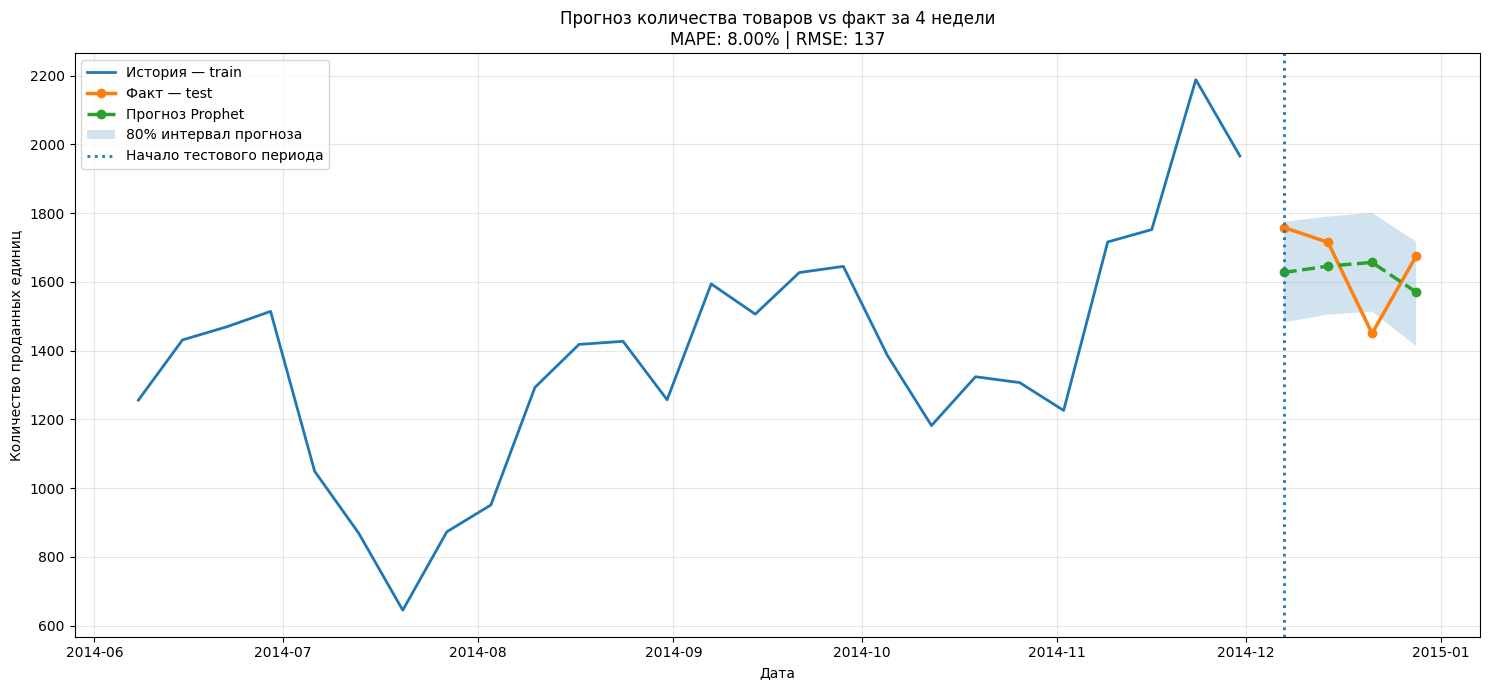

In [42]:

plt.figure(figsize=(15, 7))

quantity_train_tail = quantity_train.tail(26)

plt.plot(
    quantity_train_tail['ds'],
    quantity_train_tail['y'],
    linewidth=2,
    label='История — train'
)

plt.plot(
    quantity_results['ds'],
    quantity_results['y'],
    marker='o',
    linewidth=2.5,
    label='Факт — test'
)

plt.plot(
    quantity_results['ds'],
    quantity_results['yhat'],
    marker='o',
    linestyle='--',
    linewidth=2.5,
    label='Прогноз Prophet'
)

plt.fill_between(
    quantity_results['ds'],
    quantity_results['yhat_lower'],
    quantity_results['yhat_upper'],
    alpha=0.2,
    label='80% интервал прогноза'
)

plt.axvline(
    quantity_results['ds'].min(),
    linestyle=':',
    linewidth=2,
    label='Начало тестового периода'
)

plt.title(
    'Прогноз количества товаров vs факт за 4 недели\n'
    f'MAPE: {quantity_mape:.2f}% | '
    f'RMSE: {quantity_rmse:,.0f}'
)

plt.xlabel('Дата')
plt.ylabel('Количество проданных единиц')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [43]:

quantity_comparison = quantity_results[
    [
        'ds',
        'y',
        'yhat',
        'yhat_lower',
        'yhat_upper',
        'abs_error',
        'ape_pct'
    ]
].copy()

quantity_comparison.columns = [
    'week',
    'actual_quantity',
    'forecast_quantity',
    'forecast_lower',
    'forecast_upper',
    'absolute_error',
    'percentage_error'
]

print('Итоговая таблица прогноза количества:')
display(quantity_comparison.round(2))


quantity_comparison.to_csv(
    'quantity_forecast_vs_actual.csv',
    index=False,
    encoding='utf-8-sig'
)


save_excel_table(
    quantity_comparison,
    'quantity_forecast_vs_actual.xlsx',
    sheet_name='Quantity Forecast'
)


from google.colab import files

files.download(
    'quantity_forecast_vs_actual.csv'
)

files.download(
    'quantity_forecast_vs_actual.xlsx'
)

print(
    'Файлы quantity_forecast_vs_actual.csv и '
    'quantity_forecast_vs_actual.xlsx успешно сохранены'
)


Итоговая таблица прогноза количества:


,week,actual_quantity,forecast_quantity,forecast_lower,forecast_upper,absolute_error,percentage_error
0,2014-12-07,1758,"1,627.31","1,482.10","1,775.04",130.69,7.43
1,2014-12-14,1715,"1,645.68","1,504.65","1,789.85",69.32,4.04
2,2014-12-21,1450,"1,656.55","1,513.59","1,800.61",206.55,14.24
3,2014-12-28,1675,"1,570.09","1,412.79","1,717.00",104.91,6.26


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Файлы quantity_forecast_vs_actual.csv и quantity_forecast_vs_actual.xlsx успешно сохранены
